# 02 - Random variables and distributions

**Goal.** Collect the probability tools the rest of the course needs: random
variables, densities, expectation and variance, the standard families of
distributions (which will serve as likelihoods and priors), and the central limit
theorem. Every formula is checked numerically, and we note the parameterisation traps
that catch everyone the first time they use scipy.

## 1. Random variables, PMFs, PDFs and CDFs

A **random variable** $X$ is a numerical outcome of an experiment. It is described by
its distribution:

- **Discrete** $X$ (counts, yes/no) has a probability mass function (PMF)
  $f(x) = P(X=x)$ with $\sum_x f(x) = 1$.
- **Continuous** $X$ (times, lengths, proportions) has a probability density function
  (PDF) $f(x)\ge 0$ with $\int f(x)\,\mathrm dx = 1$, and
  $P(a\le X\le b) = \int_a^b f(x)\,\mathrm dx$. A density is not a probability: it can
  exceed 1, and $P(X=x) = 0$ for any single value.
- Both have a cumulative distribution function (CDF) $F(x) = P(X\le x)$.

**Indicator functions** keep track of where a density is non-zero.
$I_{\{x\in S\}}$ equals 1 if $x\in S$ and 0 otherwise, so the density that is $2x$ on
$[0,1]$ and zero elsewhere is written $f(x) = 2x\,I_{\{0\le x\le 1\}}$. When you
integrate, the indicator sets the limits; when you multiply densities, indicators
multiply too, which intersects their sets.

## 2. Expectation and variance

The **expectation** (mean) is the probability-weighted average of the values:
$$ \mathbb E[X] = \sum_x x\,f(x) \quad\text{or}\quad \mathbb E[X] = \int x\,f(x)\,\mathrm dx, $$
and more generally $\mathbb E[g(X)] = \int g(x)f(x)\,\mathrm dx$. Note that
$\mathbb E[g(X)] \ne g(\mathbb E[X])$ in general; we will meet an important case of
this in chapter 06.

The **variance** measures spread around the mean,
$$ \mathrm{Var}(X) = \mathbb E\big[(X-\mu)^2\big] = \mathbb E[X^2] - \big(\mathbb E[X]\big)^2, $$
and the standard deviation is its square root. For constants $a, b, c$:
$$ \mathbb E[aX+bY+c] = a\,\mathbb E[X]+b\,\mathbb E[Y]+c \quad\text{always,}\qquad
   \mathrm{Var}(aX+bY+c) = a^2\mathrm{Var}(X)+b^2\mathrm{Var}(Y) \quad\text{if } X, Y \text{ independent.} $$

**Worked example.** Let $f(x) = 2x\,I_{\{0\le x\le1\}}$. Then
$$ \mathbb E[X] = \int_0^1 x\cdot 2x\,\mathrm dx = \tfrac23, \qquad
   \mathbb E[X^2] = \int_0^1 x^2\cdot 2x\,\mathrm dx = \tfrac12, \qquad
   \mathrm{Var}(X) = \tfrac12 - \tfrac49 = \tfrac1{18}. $$
We check this two ways: by numerical integration, and by simulation. To simulate, use
the **inverse-CDF method**: here $F(x) = x^2$ on $[0,1]$, so if $U$ is uniform on
$(0,1)$ then $X = F^{-1}(U) = \sqrt U$ has density $f$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(2)

f = lambda x: 2 * x
mean = integrate.quad(lambda x: x * f(x), 0, 1)[0]
second = integrate.quad(lambda x: x**2 * f(x), 0, 1)[0]
print(f"by integration: E[X] = {mean:.4f}, Var(X) = {second - mean**2:.4f}   (exact 2/3, 1/18 = {1/18:.4f})")

x = np.sqrt(rng.random(1_000_000))        # inverse-CDF sampling
print(f"by simulation:  E[X] = {x.mean():.4f}, Var(X) = {x.var():.4f}")

by integration: E[X] = 0.6667, Var(X) = 0.0556   (exact 2/3, 1/18 = 0.0556)
by simulation:  E[X] = 0.6668, Var(X) = 0.0555


## 3. Discrete distributions

| distribution | models | PMF $f(x)$ | support | mean | variance |
|---|---|---|---|---|---|
| Bernoulli$(p)$ | one yes/no trial | $p^x(1-p)^{1-x}$ | $\{0,1\}$ | $p$ | $p(1-p)$ |
| Binomial$(n,p)$ | successes in $n$ independent trials | $\binom nx p^x(1-p)^{n-x}$ | $0,\dots,n$ | $np$ | $np(1-p)$ |
| Geometric$(p)$ | trials until the first success | $(1-p)^{x-1}p$ | $1,2,\dots$ | $1/p$ | $(1-p)/p^2$ |
| Poisson$(\lambda)$ | counts of events at rate $\lambda$ | $\lambda^x e^{-\lambda}/x!$ | $0,1,\dots$ | $\lambda$ | $\lambda$ |

A binomial is a sum of $n$ independent Bernoullis. The Poisson describes counts of
events that happen independently at a constant average rate, and it is the limit of
a Binomial$(n, \lambda/n)$ as $n\to\infty$: many opportunities, each unlikely.

**Example.** A help desk receives on average 3 calls per hour. If calls arrive as a
Poisson process, the number in an hour is $X\sim\text{Poisson}(3)$ and
$$ P(X\ge 5) = 1 - \sum_{x=0}^{4} \frac{3^x e^{-3}}{x!}. $$
The probability of a quiet two-hour stretch with no calls at all is
$P(Y=0) = e^{-6}$ for $Y\sim\text{Poisson}(6)$, because rates add over time.

P(X >= 5) by formula: 0.1847   scipy: 0.1847
P(no calls in 2 hours) = 0.00248 = e^-6 = 0.00248


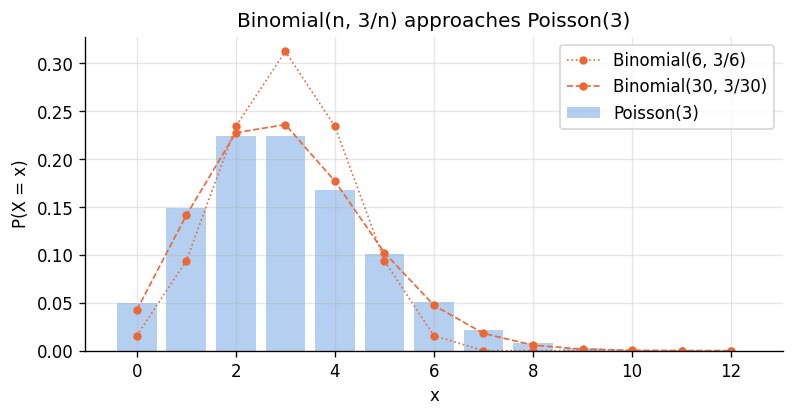

In [2]:
by_formula = 1 - sum(3**k * np.exp(-3) / np.prod(range(1, k + 1)) for k in range(5))
print(f"P(X >= 5) by formula: {by_formula:.4f}   scipy: {stats.poisson.sf(4, 3):.4f}")
print(f"P(no calls in 2 hours) = {stats.poisson.pmf(0, 6):.5f} = e^-6 = {np.exp(-6):.5f}")

# The Poisson as a limit of binomials with the same mean
k = np.arange(0, 13)
plt.bar(k, stats.poisson.pmf(k, 3), color=POST, alpha=0.35, label="Poisson(3)")
for n, style in [(6, ":"), (30, "--")]:
    plt.plot(k, stats.binom.pmf(k, n, 3 / n), "o" + style, color=LIK, ms=4, lw=1, label=f"Binomial({n}, 3/{n})")
plt.xlabel("x"); plt.ylabel("P(X = x)"); plt.title("Binomial(n, 3/n) approaches Poisson(3)")
plt.legend(); plt.show()

## 4. Continuous distributions

| distribution | models | density $f(x)$ (on its support) | support | mean | variance |
|---|---|---|---|---|---|
| Uniform$(a,b)$ | "any value in a range" | $\frac{1}{b-a}$ | $[a,b]$ | $\frac{a+b}2$ | $\frac{(b-a)^2}{12}$ |
| Exponential$(\lambda)$ | waiting time, rate $\lambda$ | $\lambda e^{-\lambda x}$ | $x\ge0$ | $1/\lambda$ | $1/\lambda^2$ |
| Gamma$(\alpha,\beta)$ | positive, right-skewed quantities | $\frac{\beta^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x}$ | $x>0$ | $\alpha/\beta$ | $\alpha/\beta^2$ |
| Beta$(\alpha,\beta)$ | proportions, probabilities | $\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}x^{\alpha-1}(1-x)^{\beta-1}$ | $(0,1)$ | $\frac{\alpha}{\alpha+\beta}$ | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ |
| Normal$(\mu,\sigma^2)$ | sums, averages, errors | $\frac{1}{\sqrt{2\pi\sigma^2}}e^{-(x-\mu)^2/(2\sigma^2)}$ | $\mathbb R$ | $\mu$ | $\sigma^2$ |
| Student $t_\nu$ | normal-like with heavier tails | $\propto\left(1+\frac{x^2}{\nu}\right)^{-(\nu+1)/2}$ | $\mathbb R$ | $0$ ($\nu>1$) | $\frac{\nu}{\nu-2}$ ($\nu>2$) |

$\Gamma$ is the gamma function, which extends the factorial: $\Gamma(n) = (n-1)!$
for positive integers. The families are connected:

- Exponential$(\lambda)$ is Gamma$(1,\lambda)$, and the sum of $n$ independent
  Exponential$(\lambda)$ waiting times is Gamma$(n,\lambda)$.
- Uniform$(0,1)$ is Beta$(1,1)$.
- If $X\sim$ Normal$(\mu,\sigma^2)$ then $(X-\mu)/\sigma\sim$ Normal$(0,1)$, and the sum of
  independent normals is normal, with means and variances adding.
- $t_\nu$ approaches Normal$(0,1)$ as $\nu\to\infty$.

**The scipy trap.** The table uses the **rate** $\beta$ for the gamma and $\lambda$
for the exponential, as most Bayesian texts do. scipy uses a **scale**, which is one
over the rate: Gamma$(\alpha,\beta)$ is `stats.gamma(a=alpha, scale=1/beta)` and
Exponential$(\lambda)$ is `stats.expon(scale=1/lam)`. Similarly `stats.norm` takes the
standard deviation, not the variance. Getting this wrong gives plausible-looking,
wrong answers, so the check below verifies the table against scipy.

Gamma(3, 2):  scipy mean 1.500 vs alpha/beta 1.500;  var 0.750 vs alpha/beta^2 0.750
Beta(2, 5):   scipy mean 0.2857 vs 0.2857;  var 0.02551 vs 0.02551
sum of 4 Exp(2): mean 1.998 (Gamma(4,2) mean 2.0),  var 0.995 (1.0)


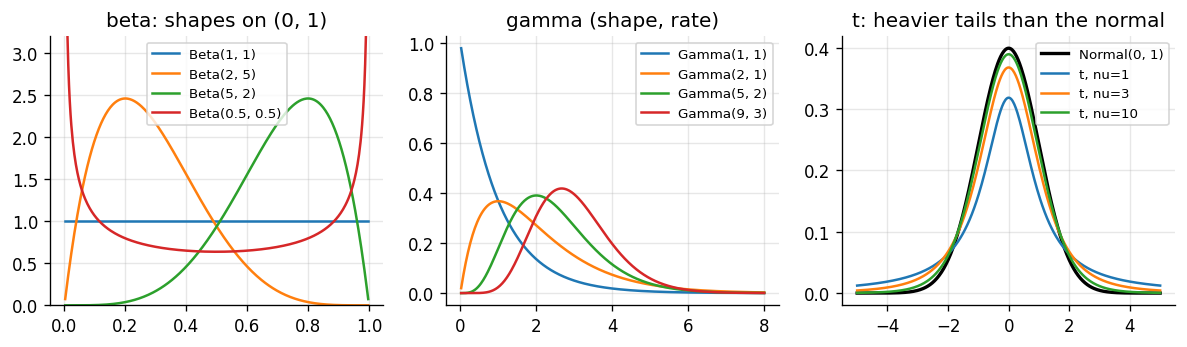

In [3]:
alpha, beta = 3.0, 2.0
g = stats.gamma(a=alpha, scale=1 / beta)                 # rate beta  <->  scale 1/beta
print(f"Gamma(3, 2):  scipy mean {g.mean():.3f} vs alpha/beta {alpha / beta:.3f};"
      f"  var {g.var():.3f} vs alpha/beta^2 {alpha / beta**2:.3f}")
b = stats.beta(2, 5)
print(f"Beta(2, 5):   scipy mean {b.mean():.4f} vs {2 / 7:.4f};  var {b.var():.5f} vs {2 * 5 / (7**2 * 8):.5f}")

# A sum of 4 Exponential(2) waiting times is Gamma(4, 2)
waits = rng.exponential(scale=1 / 2, size=(200_000, 4)).sum(axis=1)
print(f"sum of 4 Exp(2): mean {waits.mean():.3f} (Gamma(4,2) mean {4 / 2}),  var {waits.var():.3f} ({4 / 2**2})")

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
x = np.linspace(0, 1, 400)[1:-1]
for a_, b_ in [(1, 1), (2, 5), (5, 2), (0.5, 0.5)]:
    ax[0].plot(x, stats.beta.pdf(x, a_, b_), label=f"Beta({a_}, {b_})")
ax[0].set_ylim(0, 3.2); ax[0].set_title("beta: shapes on (0, 1)"); ax[0].legend(fontsize=8)
x = np.linspace(0, 8, 400)[1:]
for a_, b_ in [(1, 1), (2, 1), (5, 2), (9, 3)]:
    ax[1].plot(x, stats.gamma.pdf(x, a_, scale=1 / b_), label=f"Gamma({a_}, {b_})")
ax[1].set_title("gamma (shape, rate)"); ax[1].legend(fontsize=8)
x = np.linspace(-5, 5, 400)
ax[2].plot(x, stats.norm.pdf(x), "k", lw=2, label="Normal(0, 1)")
for nu in [1, 3, 10]:
    ax[2].plot(x, stats.t.pdf(x, nu), label=f"t, nu={nu}")
ax[2].set_title("t: heavier tails than the normal"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. The central limit theorem

Let $X_1,\dots,X_n$ be independent and identically distributed with mean $\mu$ and
finite variance $\sigma^2$, and let $\bar X_n = \frac1n\sum_i X_i$. Then
$$ \frac{\sqrt n\,(\bar X_n - \mu)}{\sigma} \;\longrightarrow\; \text{Normal}(0,1) \quad\text{as } n\to\infty. $$
In words: whatever the shape of the individual $X_i$, their average is approximately
normal with mean $\mu$ and standard deviation $\sigma/\sqrt n$ once $n$ is moderately
large. That is why normal distributions show up everywhere measurements are sums of
many small effects, and it is why the frequentist intervals of chapter 03 and the
posterior approximations of later chapters work.

The simulation below averages draws from a very skewed distribution,
Exponential(1), which has $\mu=\sigma=1$. A single draw looks nothing like a normal;
the average of 5 is less skewed; the average of 30 is close to the normal curve with
standard deviation $1/\sqrt{30}$.

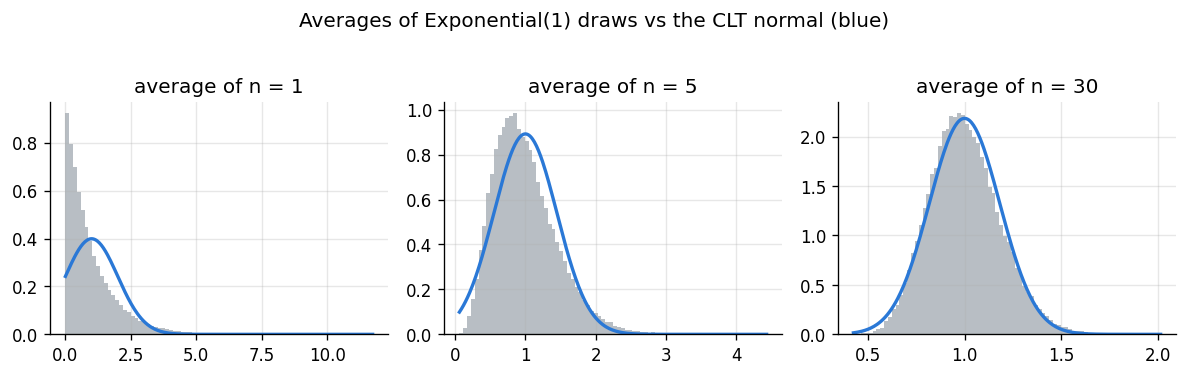

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), sharey=False)
for a, n in zip(ax, [1, 5, 30]):
    means = rng.exponential(1.0, size=(100_000, n)).mean(axis=1)
    a.hist(means, bins=80, density=True, color=PRIOR, alpha=0.6)
    grid = np.linspace(means.min(), means.max(), 300)
    a.plot(grid, stats.norm.pdf(grid, 1, 1 / np.sqrt(n)), color=POST, lw=2)
    a.set_title(f"average of n = {n}")
fig.suptitle("Averages of Exponential(1) draws vs the CLT normal (blue)", y=1.03)
plt.tight_layout(); plt.show()

## 6. Bayes' theorem for densities

Chapter 01 had a finite set of hypotheses. When the unknown $\theta$ is continuous,
the prior is a density $p(\theta)$, the likelihood is the density of the data
$p(y\mid\theta)$, and the sum over hypotheses becomes an integral:
$$ p(\theta\mid y) = \frac{p(y\mid\theta)\,p(\theta)}{\int p(y\mid\theta')\,p(\theta')\,\mathrm d\theta'}. $$
It is the same theorem. Chapter 04 puts it to work; chapter 03 first looks at the
likelihood on its own, which is how classical statistics uses it.

### Exercises

1. For $f(x) = 3x^2 I_{\{0\le x\le1\}}$, find $\mathbb E[X]$, $\mathrm{Var}(X)$ and a
   sampler based on the inverse CDF. Check all three in code.
2. Show that $\mathbb E[1/X] \ne 1/\mathbb E[X]$ for $X\sim$ Gamma$(3, 2)$ by computing
   both. (You will need $\mathbb E[1/X] = \beta/(\alpha-1)$ for $\alpha>1$; prove it
   by writing the integral and recognising a gamma density.)
3. Calls arrive at rate 3 per hour. What is the distribution of the waiting time until
   the fifth call, and its mean? Verify by simulation.
4. Repeat the CLT experiment with a Bernoulli(0.05) variable. How large must $n$ be
   before the histogram of averages looks normal? Why is it slower than for the
   exponential?
5. Show that the Beta$(\alpha,\beta)$ density with $\alpha,\beta>1$ has its mode at
   $(\alpha-1)/(\alpha+\beta-2)$.

## References

1. J. Blitzstein, J. Hwang. *Introduction to Probability*, 2nd ed. CRC Press, 2019.
2. G. Casella, R. L. Berger. *Statistical Inference*, 2nd ed. Duxbury, 2002. (Chapters 2-3: expectations and the common families.)
3. L. Wasserman. *All of Statistics.* Springer, 2004. (Chapter 5: convergence and the central limit theorem.)
4. N. L. Johnson, S. Kotz, N. Balakrishnan. *Continuous Univariate Distributions*, Vols. 1-2, 2nd ed. Wiley, 1994-1995.
5. P. Virtanen et al. *SciPy 1.0: fundamental algorithms for scientific computing in Python.* Nature Methods, 17:261-272, 2020. doi:10.1038/s41592-019-0686-2